# china-ashare-market-style-monitor

## 1. Introduction

## Project background
Most stock market apps mainly show daily information, such as sector heatmaps, top gainers, and short-term price movements. However, they often do not provide a clear view of the broader market environment.

In the China A-share market, different periods are often associated with different market styles, such as large-cap blue-chip leadership, balanced performance, or growth-active leadership. However, short-term market movements are often noisy, and many investors may still find it difficult to form a clear view of the broader market context.

As a result, retail investors may struggle to identify the dominant market style at present, and whether a style shift has occurred, which means they often lack a basis for judging what types of stocks are aligned with the market’s medium- to long-term main direction when selecting stocks.

## Target Users
The primary users of this product are China A-share retail investors who already follow the market and have basic investment knowledge, but do not yet have a structured framework for understanding market style.

This product is especially useful for users who can observe daily market movements, but still find it difficult to judge whether the market is currently led by large-cap, balanced, or growth-active styles, and whether a style shift may have occurred.

It may also be useful for finance students, beginner analysts, and financial information platforms that want to provide a clearer summary of the broader market environment.

## Product Need
In practice, predicting prices and forecasting the exact direction of the market is always difficult. Instead of trying to predict every market move, a more realistic approach is to understand the market as it is now and respond to it. In other words, the purpose is not to predict, but to interpret the current market environment more clearly.

Therefore, this project aims to build a simple market style monitor that helps users identify the past 12-month market style, the current market style, and whether a style shift may have occurred.

## Product Overview
This product is a market style monitor based on major China A-share broad indices. It classifies the indices into three dimensions:

- **Size**: large-cap, mid-cap, small-cap
- **Elasticity**: low, medium, high
- **Style orientation**: blue-chip core, balanced, growth-active

The analysis is divided into two parts:
- **Price-based analysis**, which is used to identify the market style over the past 12 months and the current market style
- **Activity-based analysis**, which is used to check whether the current market style is supported by trading amount and trading volume

The final output provides a simple summary of the market style over the past 12 months, the current market style, and whether a style shift may have happened.


In [12]:
# Import the libraries needed for data retrieval, cleaning, analysis, and plotting in this project
import os
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import tushare as ts
##Data source: Tushare Pro(https://tushare.pro/), accessed on 2026-04-20

## 2. Data Source and Included Indices

### Data source
This notebook supports direct Tushare Pro API(https://tushare.pro/) calls to fetch index daily data.

### Main fields
The main fields used in the analysis are:
- `date`
- `index`
- `close`
- `amount`
- `volume`

### Included indices
- SSE50
- CSI A50
- CSI 300
- SZSE 100
- CSI 500
- ChiNext
- STAR 50
- CSI 1000
- CSI 2000
- Beijing 50

These indices are included because together they provide relatively broad coverage of the China A-share market across different styles. 


In [13]:
# Define the index metadata and create reusable lists and mappings for later analysis

index_info_list = [
    {"index": "SSE50", "index_cn": "上证50", "ts_code": "000016.SH"},
    {"index": "CSI A50", "index_cn": "中证A50", "ts_code": "930050.CSI"},
    {"index": "CSI 300", "index_cn": "沪深300", "ts_code": "000300.SH"},
    {"index": "SZSE 100", "index_cn": "深证100", "ts_code": "399330.SZ"},
    {"index": "CSI 500", "index_cn": "中证500", "ts_code": "000905.SH"},
    {"index": "ChiNext", "index_cn": "创业板指", "ts_code": "399006.SZ"},
    {"index": "STAR 50", "index_cn": "科创50", "ts_code": "000688.SH"},
    {"index": "CSI 1000", "index_cn": "中证1000", "ts_code": "000852.SH"},
    {"index": "CSI 2000", "index_cn": "中证2000", "ts_code": "932000.CSI"},
    {"index": "Beijing 50", "index_cn": "北证50", "ts_code": "899050.BJ"},
]
## This project retains Chinese index names for users familiar with them.

## Keep a simple list of English index names for later loops
included_indices = []
for item in index_info_list:
    included_indices.append(item["index"])
## Build a mapping from English index name to Chinese display name
index_cn_name_map = {}
for item in index_info_list:
    index_cn_name_map[item["index"]] = item["index_cn"]

info_df = pd.DataFrame(index_info_list)

## Check and confirm
print("included indices:")
print(info_df.to_markdown(index=False))

included indices:
| index      | index_cn   | ts_code    |
|:-----------|:-----------|:-----------|
| SSE50      | 上证50     | 000016.SH  |
| CSI A50    | 中证A50    | 930050.CSI |
| CSI 300    | 沪深300    | 000300.SH  |
| SZSE 100   | 深证100    | 399330.SZ  |
| CSI 500    | 中证500    | 000905.SH  |
| ChiNext    | 创业板指   | 399006.SZ  |
| STAR 50    | 科创50     | 000688.SH  |
| CSI 1000   | 中证1000   | 000852.SH  |
| CSI 2000   | 中证2000   | 932000.CSI |
| Beijing 50 | 北证50     | 899050.BJ  |


## 3. Data Loading and Inspection

This section loads the local dataset and performs basic inspection and cleaning. This section will complete:
1. Data loading:
   - Connect to Tushare
   - Automatically incrementally update local CSV (avoid full reload each time)
   - Read CSV
Interpretation(How to get data):
    ### Default mode
    By default, the notebook runs from the local CSV file, so a Tushare account is not required for normal use.

    ### Update mode
    Tushare is only needed when the user wants to update the dataset. In that case, the user needs to prepare:
   - a valid Tushare token
   - the required Python package environment
   - working access to the Tushare API
   - change the following "AUTO_UPDATE_FROM_TUSHARE = False" to AUTO_UPDATE_FROM_TUSHARE = True"

2. Basic inspection and cleaning:
   - Checking the basic structure of the data,
   - Sorting the observations by index and date,
   - Removing rows with missing values in key fields.

In [14]:
# Prepare the local storage path and Tushare connection for data updating

LOCAL_CSV_PATH = "a_share_indices_daily.csv"

## For subsequent data update confirmation
AUTO_UPDATE_FROM_TUSHARE = False

## Connected to Tushare(optional)
TUSHARE_TOKEN = ""   # fill only when AUTO_UPDATE_FROM_TUSHARE = True
TUSHARE_URL = ""     # optional
pro = None

if AUTO_UPDATE_FROM_TUSHARE:
    pro = ts.pro_api(TUSHARE_TOKEN)
    if TUSHARE_URL.strip() != "":
        pro._DataApi__http_url = TUSHARE_URL
        
DEFAULT_START_DATE = "20250101"  # Start date for first pull of a new file (YYYYMMDD)

## Set end date with a unified fallback rule:
## If today has no data, automatically roll back to the latest available trade date.
def get_latest_trade_date_on_or_before_today(pro_api, index_meta_list, today_text):
    today_dt = datetime.strptime(today_text, "%Y%m%d")
    start_dt = today_dt - timedelta(days=40)
    start_text = start_dt.strftime("%Y%m%d")

    latest_trade_date = ""
    for item in index_meta_list:
        ts_code = item["ts_code"]
        raw_df = pro_api.index_daily(
            ts_code=ts_code,
            start_date=start_text,
            end_date=today_text,
            fields="trade_date",
        )

        raw_df = raw_df.sort_values("trade_date")
        trade_date_list = list(raw_df["trade_date"])
        one_latest = str(trade_date_list[-1])

        if latest_trade_date == "" or one_latest > latest_trade_date:
            latest_trade_date = one_latest

    return latest_trade_date

TODAY_TEXT = datetime.now().strftime("%Y%m%d")

if AUTO_UPDATE_FROM_TUSHARE:
    END_DATE = get_latest_trade_date_on_or_before_today(pro, index_info_list, TODAY_TEXT)
else:
    local_df = pd.read_csv(LOCAL_CSV_PATH)
    END_DATE = str(local_df["date"].max()).replace("-", "")
    
print("Current END_DATE:", END_DATE)

Current END_DATE: 20260420


In [15]:
# Basic helper functions for this project.
# Including small reusable functions for displaying tables,converting and updating date text, and loading the local dataset.

## Show a small dataframe for basic data check and confirmation
def show_table(df, title, max_rows=10):
    print(title)
    small_df = df.head(max_rows).copy()
    print(small_df)


## Convert tushare date format (YYYYMMDD) to notebook date format (YYYY-MM-DD)
def yyyymmdd_to_yyyy_mm_dd(date_text):
    text = str(date_text)
    year_part = text[0:4]
    month_part = text[4:6]
    day_part = text[6:8]
    return year_part + "-" + month_part + "-" + day_part


def next_day_yyyymmdd(date_text_yyyy_mm_dd):
    now_dt = datetime.strptime(date_text_yyyy_mm_dd, "%Y-%m-%d")
    next_dt = now_dt + timedelta(days=1)
    next_text = next_dt.strftime("%Y%m%d")
    return next_text

## Load the local CSV file and return it as a pandas DataFrame
def load_local_csv(csv_path):
    raw_df = pd.read_csv(csv_path)
    # Keep only required columns used by downstream analysis
    return raw_df[["date", "index", "close", "amount", "volume"]].copy()

## Find the latest saved date for one index, later used in the CSV update step to fetch only newly added data
def get_last_saved_date(local_df, index_name):
    sub_df = local_df[local_df["index"] == index_name]
    last_date = sub_df["date"].max()
    return last_date

## Fetch daily data for one index from Tushare and convert it into the standard format used in this project
def fetch_daily_data_for_one_index(pro_api, ts_code, index_name, start_date, end_date):
    output_rows = []
    raw_df = pro_api.index_daily(
        ts_code=ts_code,
        start_date=start_date,
        end_date=end_date,
        fields="ts_code,trade_date,close,vol,amount",
    )
    
    ### If the returned data is abnormal, stop and return an empty table.(
    if raw_df is None or "trade_date" not in raw_df.columns:
        print(f"[Warning] {index_name} API returned abnormal data (missing trade_date). Skip this pull.")
        return pd.DataFrame(columns=["date", "index", "close", "amount", "volume"])

    raw_df = raw_df.sort_values("trade_date")
   
    trade_date_list = list(raw_df["trade_date"])
    close_list = list(raw_df["close"])
    amount_list = list(raw_df["amount"])
    vol_list = list(raw_df["vol"])

    for i in range(len(raw_df)):
        one_date = yyyymmdd_to_yyyy_mm_dd(trade_date_list[i])
        one_close = close_list[i]
        one_amount = amount_list[i]
        one_volume = vol_list[i]

        row = {
            "date": str(one_date),
            "index": index_name,
            "close": float(one_close),
            "amount": float(one_amount),
            "volume": float(one_volume),
        }
        output_rows.append(row)

    output_df = pd.DataFrame(output_rows, columns=["date", "index", "close", "amount", "volume"])
    return output_df

## Update the local CSV file with the latest index data from Tushare
### These functions support incremental updates so that only newly added records need to be downloaded.
def update_csv_from_tushare(csv_path, default_start_date, end_date_text):
    local_df = load_local_csv(csv_path)
    
    all_new_rows = []
    for item in index_info_list:
        index_name = item["index"]
        ts_code = item["ts_code"]
        last_saved = get_last_saved_date(local_df, index_name)
        #### If the user extracts data during a trading day/holiday, ensure the update date is the last trading day with available data.
        if pd.isna(last_saved):
            fetch_start = default_start_date
        else:
            fetch_start = next_day_yyyymmdd(last_saved)

        if fetch_start > end_date_text:
            continue

        print(f"{index_name}: {fetch_start} -> {end_date_text}")
        new_df = fetch_daily_data_for_one_index(
            pro_api=pro,
            ts_code=ts_code,
            index_name=index_name,
            start_date=fetch_start,
            end_date=end_date_text,
        )

        new_date_list = list(new_df["date"])
        new_index_list = list(new_df["index"])
        new_close_list = list(new_df["close"])
        new_amount_list = list(new_df["amount"])
        new_volume_list = list(new_df["volume"])

        for i in range(len(new_df)):
            row = {
                "date": str(new_date_list[i]),
                "index": str(new_index_list[i]),
                "close": float(new_close_list[i]),
                "amount": float(new_amount_list[i]),
                "volume": float(new_volume_list[i]),
            }
            all_new_rows.append(row)

    combined_rows = []

    local_date_list = list(local_df["date"])
    local_index_list = list(local_df["index"])
    local_close_list = list(local_df["close"])
    local_amount_list = list(local_df["amount"])
    local_volume_list = list(local_df["volume"])

    for i in range(len(local_df)):
        row = {
            "date": str(local_date_list[i]),
            "index": str(local_index_list[i]),
            "close": float(local_close_list[i]),
            "amount": float(local_amount_list[i]),
            "volume": float(local_volume_list[i]),
        }
        combined_rows.append(row)

    for row in all_new_rows:
        combined_rows.append(row)

    ### Deduplicate by (date, index): keep the latest record for each key
    dedup_map = {}
    for row in combined_rows:
        key = str(row["date"]) + "|" + str(row["index"])
        dedup_map[key] = row

    dedup_rows = []
    for key in dedup_map:
        dedup_rows.append(dedup_map[key])

    output_df = pd.DataFrame(dedup_rows, columns=["date", "index", "close", "amount", "volume"])
    output_df = output_df.sort_values(["index", "date"]).copy()

    output_df.to_csv(csv_path, index=False)
    print(f"Update finished. Written to: {csv_path},Total rows: {len(output_df)}")

In [16]:
# Load, sort, and clean the local index dataset before analysis
if AUTO_UPDATE_FROM_TUSHARE:
    print("Running data update")
    update_csv_from_tushare(
        csv_path=LOCAL_CSV_PATH,
        default_start_date=DEFAULT_START_DATE,
        end_date_text=END_DATE,
    )

market_df = load_local_csv(LOCAL_CSV_PATH)

## Data preview
show_table(market_df, "Raw data preview (head)", max_rows=8)
print("\nRaw dtypes:")
print(market_df.dtypes)

## Sort the data by date
market_df = market_df.sort_values(by=["index", "date"], ascending=[True, True]).copy()

## Remove rows with missing core fields before any return/activity calculation
market_df = market_df[
    market_df["date"].notna()
    & market_df["index"].notna()
    & market_df["close"].notna()
    & market_df["amount"].notna()
    & market_df["volume"].notna()
].copy()

Raw data preview (head)
         date       index      close        amount       volume
0  2025-01-02  Beijing 50  1019.8776  1.324876e+07   7543876.80
1  2025-01-03  Beijing 50  1018.1664  1.459733e+07   8352396.17
2  2025-01-06  Beijing 50  1003.6427  1.272115e+07   7686193.04
3  2025-01-07  Beijing 50  1024.4156  1.268141e+07   7687642.52
4  2025-01-08  Beijing 50  1037.3981  1.481062e+07   8772397.56
5  2025-01-09  Beijing 50  1053.5290  1.766925e+07  10081530.53
6  2025-01-10  Beijing 50  1024.2590  1.484717e+07   8430121.72
7  2025-01-13  Beijing 50  1000.2155  9.961789e+06   5811699.82

Raw dtypes:
date       object
index      object
close     float64
amount    float64
volume    float64
dtype: object


In [17]:
# Check if the data is updated
print("Data Update Check:")
latest_date_all = market_df["date"].max()
print("Latest date in local dataset:", latest_date_all)
print("Latest date by index:")
for idx_name in included_indices:
    sub_df = market_df[market_df["index"] == idx_name]
    latest_date_one = sub_df["date"].max()
    print(idx_name, ":", latest_date_one)

Data Update Check:
Latest date in local dataset: 2026-04-20
Latest date by index:
SSE50 : 2026-04-20
CSI A50 : 2026-04-20
CSI 300 : 2026-04-20
SZSE 100 : 2026-04-20
CSI 500 : 2026-04-20
ChiNext : 2026-04-20
STAR 50 : 2026-04-20
CSI 1000 : 2026-04-20
CSI 2000 : 2026-04-20
Beijing 50 : 2026-04-20


## 4. Index Classification Framework

To make the market style analysis more structured, the included broad indices are classified into three dimensions(Size\Elasticity\Syle orientation):

- SSE50 -> Large / Low / Blue-chip Core
- CSI A50 -> Large / Low / Blue-chip Core
- CSI 300 -> Large / Low / Balanced
- SZSE 100 -> Large / Medium / Balanced
- CSI 500 -> Mid / Medium / Balanced
- ChiNext -> Mid / High / Growth-Active
- STAR 50 -> Mid / High / Growth-Active
- CSI 1000 -> Small / High / Growth-Active
- CSI 2000 -> Small / High / Growth-Active
- Beijing 50 -> Small / High / Growth-Active

his classification helps group the broad indices into a clearer market-style framework. It is mainly used for practical analysis rather than strict academic classification. The later analysis focuses on category-level results, not only on individual indices.

In [18]:
# Define the index classification framework and attach category labels to the dataset.
classification_rows = [
    {"index": "SSE50", "index_cn": "上证50", "size": "Large", "elasticity": "Low", "style_orientation": "Blue-chip Core"},
    {"index": "CSI A50", "index_cn": "中证A50", "size": "Large", "elasticity": "Low", "style_orientation": "Blue-chip Core"},
    {"index": "CSI 300", "index_cn": "沪深300", "size": "Large", "elasticity": "Low", "style_orientation": "Balanced"},
    {"index": "SZSE 100", "index_cn": "深证100", "size": "Large", "elasticity": "Medium", "style_orientation": "Balanced"},
    {"index": "CSI 500", "index_cn": "中证500", "size": "Mid", "elasticity": "Medium", "style_orientation": "Balanced"},
    {"index": "ChiNext", "index_cn": "创业板指", "size": "Mid", "elasticity": "High", "style_orientation": "Growth-Active"},
    {"index": "STAR 50", "index_cn": "科创50", "size": "Mid", "elasticity": "High", "style_orientation": "Growth-Active"},
    {"index": "CSI 1000", "index_cn": "中证1000", "size": "Small", "elasticity": "High", "style_orientation": "Growth-Active"},
    {"index": "CSI 2000", "index_cn": "中证2000", "size": "Small", "elasticity": "High", "style_orientation": "Growth-Active"},
    {"index": "Beijing 50", "index_cn": "北证50", "size": "Small", "elasticity": "High", "style_orientation": "Growth-Active"},
]
classification_df = pd.DataFrame(classification_rows)

size_map = {}
elasticity_map = {}
style_map = {}

index_list = list(classification_df["index"])
size_list = list(classification_df["size"])
elasticity_list = list(classification_df["elasticity"])
style_list = list(classification_df["style_orientation"])

## Build mapping dictionaries from index name to each classification label
for i in range(len(index_list)):
    idx_name = index_list[i]
    size_map[idx_name] = size_list[i]
    elasticity_map[idx_name] = elasticity_list[i]
    style_map[idx_name] = style_list[i]

size_col = []
elasticity_col = []
style_col = []
index_cn_col = []

## Add the classification results back to the main market dataset
for idx_name in market_df["index"]:
    size_col.append(size_map[idx_name])
    elasticity_col.append(elasticity_map[idx_name])
    style_col.append(style_map[idx_name])
    index_cn_col.append(index_cn_name_map[idx_name])

market_df["size"] = size_col
market_df["elasticity"] = elasticity_col
market_df["style_orientation"] = style_col
market_df["index_cn"] = index_cn_col

show_table(market_df, "Data preview after adding classification", max_rows=8)


Data preview after adding classification
         date       index      close        amount       volume   size  \
0  2025-01-02  Beijing 50  1019.8776  1.324876e+07   7543876.80  Small   
1  2025-01-03  Beijing 50  1018.1664  1.459733e+07   8352396.17  Small   
2  2025-01-06  Beijing 50  1003.6427  1.272115e+07   7686193.04  Small   
3  2025-01-07  Beijing 50  1024.4156  1.268141e+07   7687642.52  Small   
4  2025-01-08  Beijing 50  1037.3981  1.481062e+07   8772397.56  Small   
5  2025-01-09  Beijing 50  1053.5290  1.766925e+07  10081530.53  Small   
6  2025-01-10  Beijing 50  1024.2590  1.484717e+07   8430121.72  Small   
7  2025-01-13  Beijing 50  1000.2155  9.961789e+06   5811699.82  Small   

  elasticity style_orientation index_cn  
0       High     Growth-Active     北证50  
1       High     Growth-Active     北证50  
2       High     Growth-Active     北证50  
3       High     Growth-Active     北证50  
4       High     Growth-Active     北证50  
5       High     Growth-Active     北证50 

## 5. Price-Based Style Analysis

This section examines market style from the perspective of price performance.

The analysis focuses on two time windows:
- past 12 months: Representing the longer-term market style,
- recent 3 months: Representing the current market style.

For each index, trailing returns are calculated for these two periods. Then, within each of the three dimensions(size, elasticity, and style orientation)category-level returns are calculated using simple equal-weight averages.

This allows the notebook to answer three questions:
1. What style dominated the market over the past 12 months?
2. What style is dominant in the current period?
3. Has a style shift occurred?

If the same category leads in both the past 12 months and the current quarter, the style is interpreted as broadly persistent. If the leading category changes, the notebook treats this as a possible style shift.

In [19]:
# Price-based analysis functions
# This block first calculates past-12-month and current-quarter returns for each individual index
# Then aggregates the results into category-level summaries across size, elasticity, and style orientation.
# At last, identifies the leading styles in each dimension, checks whether a style shift has occurred and prints a concise summary of the main return-based findings.

## Calculate past-12-month and current-quarter returns for one index
def compute_returns_for_one_index(index_df, index_name):
    index_df = index_df.sort_values("date")
    close_list = list(index_df["close"])
    date_list = list(index_df["date"])

    latest_close = float(close_list[-1])

    result = {
        "index": index_name,
        "latest_date": date_list[-1],
        "latest_close": latest_close,
        # 3M return uses 60 trading days; 12M return uses 240 trading days
        "return_3m": latest_close / float(close_list[-61]) - 1,
        "return_12m": latest_close / float(close_list[-241]) - 1,
    }
    return result

## Aggregate index-level results into category-level results using simple equal-weight averages
def aggregate_by_category(index_level_df, category_column, value_columns):
    categories = []
    for cat in index_level_df[category_column]:
        if cat not in categories:
            categories.append(cat)

    output_rows = []
    for cat in categories:
        one_row = {category_column: cat}
        sub_df = index_level_df[index_level_df[category_column] == cat]

        for val_col in value_columns:
            values = list(sub_df[val_col])
            one_row[val_col] = sum(values) / len(values)

        output_rows.append(one_row)

    return pd.DataFrame(output_rows)

## Find the leading category based on the selected return column
def get_leader(category_df, category_column, value_column):
    category_list = list(category_df[category_column])
    value_list = list(category_df[value_column])

    leader_name = category_list[0]
    leader_value = float(value_list[0])

    for i in range(1, len(category_df)):
        cat = category_list[i]
        val = float(value_list[i])
        if val > leader_value:
            leader_name = cat
            leader_value = val

    return leader_name, leader_value

## Generate a text conclusion about past style, current style, and possible style shift
def make_price_conclusion(category_df, category_column, dimension_name):
    current_leader, current_val = get_leader(category_df, category_column, "return_3m")
    past_leader, past_val = get_leader(category_df, category_column, "return_12m")

    if past_leader != current_leader:
        style_changed = True
    else:
        style_changed = False

    leader_info = {
        "past_leader_12m": past_leader,
        "past_val_12m": past_val,
        "current_leader_3m": current_leader,
        "current_val_3m": current_val,
        "style_changed": style_changed,
    }
    return leader_info

## Build an index-level return result table for all included indices
return_rows = []
for idx_name in included_indices:
    one_index_df = market_df[market_df["index"] == idx_name].copy()
    one_result = compute_returns_for_one_index(one_index_df, idx_name)
    one_result["index_cn"] = index_cn_name_map[idx_name]
    one_result["size"] = size_map[idx_name]
    one_result["elasticity"] = elasticity_map[idx_name]
    one_result["style_orientation"] = style_map[idx_name]
    return_rows.append(one_result)

returns_index_df = pd.DataFrame(return_rows)

## Aggregate index-level returns into category-level return tables
size_return_df = aggregate_by_category(returns_index_df, "size", ["return_3m", "return_12m"])
elasticity_return_df = aggregate_by_category(returns_index_df, "elasticity", ["return_3m", "return_12m"])
style_return_df = aggregate_by_category(returns_index_df, "style_orientation", ["return_3m", "return_12m"])

## Identify past-12-month leader, current-3-month leader and style-change information for each of the three dimensions 
size_leaders = make_price_conclusion(size_return_df, "size", "Size")
elasticity_leaders = make_price_conclusion(elasticity_return_df, "elasticity", "Elasticity")
style_leaders = make_price_conclusion(style_return_df, "style_orientation", "Style Orientation")

## summary for past-12-month
summary_12m = "Three-dimension summary for past 12 months:"
summary_12m += f"Size={size_leaders['past_leader_12m']} (12M={size_leaders['past_val_12m']:.2%}). "
summary_12m += f"Elasticity={elasticity_leaders['past_leader_12m']} (12M={elasticity_leaders['past_val_12m']:.2%}). "
summary_12m += f"Style Orientation={style_leaders['past_leader_12m']} (12M={style_leaders['past_val_12m']:.2%})."

top3_12m_df = returns_index_df.sort_values(by="return_12m", ascending=False).head(3).copy()
top3_12m_index = list(top3_12m_df["index"])
top3_12m_cn = list(top3_12m_df["index_cn"])
top3_12m_ret = list(top3_12m_df["return_12m"])

## summary for current-3-month
summary_3m = "Three-dimension summary for past 3 months:"
summary_3m += f"Size={size_leaders['current_leader_3m']} (3M={size_leaders['current_val_3m']:.2%}). "
summary_3m += f"Elasticity={elasticity_leaders['current_leader_3m']} (3M={elasticity_leaders['current_val_3m']:.2%}). "
summary_3m += f"Style Orientation={style_leaders['current_leader_3m']} (3M={style_leaders['current_val_3m']:.2%})."


top3_3m_df = returns_index_df.sort_values(by="return_3m", ascending=False).head(3).copy()
top3_3m_index = list(top3_3m_df["index"])
top3_3m_cn = list(top3_3m_df["index_cn"])
top3_3m_ret = list(top3_3m_df["return_3m"])

## show the resault
print("\n[Return Data Summary]")
print(summary_12m)
print("Top 3 indices by 12M return:")
for i in range(3):
    print(f"{i+1}. {top3_12m_index[i]}({top3_12m_cn[i]}): {top3_12m_ret[i]:.2%}")

print(summary_3m)
print("Top 3 indices by 3M return:")
for i in range(3):
    print(f"{i+1}. {top3_3m_index[i]}({top3_3m_cn[i]}): {top3_3m_ret[i]:.2%}")


[Return Data Summary]
Three-dimension summary for past 12 months:Size=Mid (12M=60.28%). Elasticity=Medium (12M=46.84%). Style Orientation=Growth-Active (12M=44.93%).
Top 3 indices by 12M return:
1. ChiNext(创业板指): 90.70%
2. CSI 500(中证500): 47.40%
3. SZSE 100(深证100): 46.29%
Three-dimension summary for past 3 months:Size=Mid (3M=2.37%). Elasticity=Medium (3M=3.59%). Style Orientation=Balanced (3M=2.44%).
Top 3 indices by 3M return:
1. ChiNext(创业板指): 9.19%
2. SZSE 100(深证100): 6.37%
3. CSI 2000(中证2000): 2.22%


### Visualization 1: Normalized index price lines (Base=100)



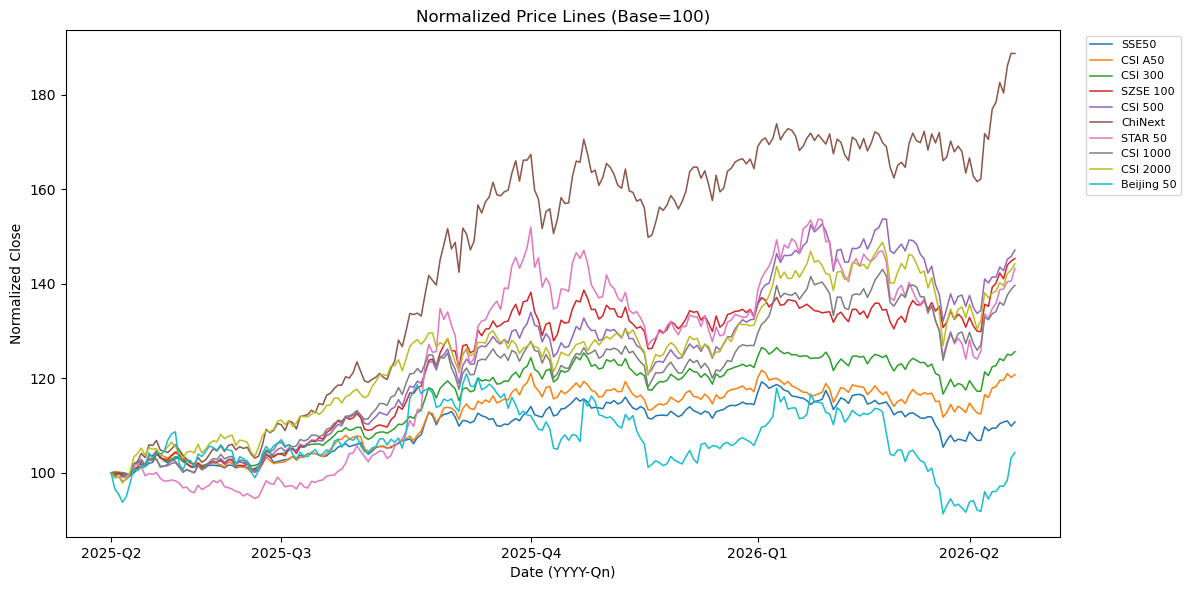

In [20]:
plt.figure(figsize=(12, 6))
lookback_days_for_plot = 240

# Use one index date series as x-axis reference for quarter labels
plot_date_reference = []

for idx_name in included_indices:
    one_index_df = market_df[market_df["index"] == idx_name].copy()
    one_index_df = one_index_df.sort_values("date").copy()

    if len(one_index_df) == 0:
        continue

    date_list = list(one_index_df["date"])
    close_list = list(one_index_df["close"])

    if len(one_index_df) > lookback_days_for_plot:
        date_list = date_list[-lookback_days_for_plot:]
        close_list = close_list[-lookback_days_for_plot:]

    if len(plot_date_reference) == 0:
        plot_date_reference = date_list

    base_close = float(close_list[0])
    if base_close == 0:
        continue

    norm_prices = []
    for px in close_list:
        norm_value = float(px) / base_close * 100
        norm_prices.append(norm_value)

    plt.plot(date_list, norm_prices, label=idx_name, linewidth=1.1)

# Build quarter tick labels: YYYY-Qn
quarter_tick_positions = []
quarter_tick_labels = []
last_quarter_key = ""

for one_date in plot_date_reference:
    date_text = str(one_date)
    year_text = date_text[0:4]
    month_text = date_text[5:7]

    quarter_key = ""
    if month_text == "01":
        quarter_key = year_text + "-Q1"
    elif month_text == "04":
        quarter_key = year_text + "-Q2"
    elif month_text == "07":
        quarter_key = year_text + "-Q3"
    elif month_text == "10":
        quarter_key = year_text + "-Q4"

    if quarter_key != "" and quarter_key != last_quarter_key:
        quarter_tick_positions.append(one_date)
        quarter_tick_labels.append(quarter_key)
        last_quarter_key = quarter_key

if len(quarter_tick_positions) > 0:
    plt.xticks(quarter_tick_positions, quarter_tick_labels)

plt.title("Normalized Price Lines (Base=100)")
plt.xlabel("Date (YYYY-Qn)")
plt.ylabel("Normalized Close")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
plt.tight_layout()
plt.show()

### Visualization 2: Index-level 3M / 12M returns
This chart shows each index’s 3M and 12M returns side by side.  
It helps us compare short-term versus longer-term performance at the individual index level.

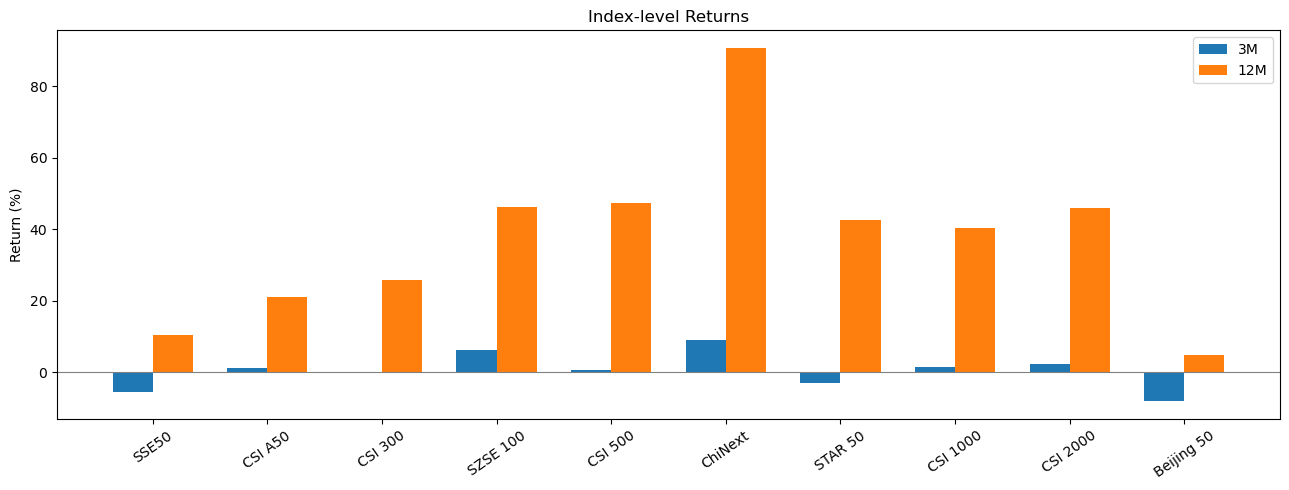

In [21]:
def value_or_zero_for_plot(v):
    if pd.isna(v):
        return 0
    return float(v)


plot_df = returns_index_df.copy()
x_labels = list(plot_df["index"])
x_pos = list(range(len(x_labels)))

r3 = []
r12 = []
plot_r3_list = list(plot_df["return_3m"])
plot_r12_list = list(plot_df["return_12m"])
for i in range(len(plot_df)):
    v3 = value_or_zero_for_plot(plot_r3_list[i]) * 100
    v12 = value_or_zero_for_plot(plot_r12_list[i]) * 100

    r3.append(v3)
    r12.append(v12)

bar_w = 0.35
plt.figure(figsize=(13, 5))
plt.bar([x - bar_w / 2 for x in x_pos], r3, width=bar_w, label="3M")
plt.bar([x + bar_w / 2 for x in x_pos], r12, width=bar_w, label="12M")
plt.axhline(0, color="gray", linewidth=0.8)
plt.xticks(x_pos, x_labels, rotation=35)
plt.ylabel("Return (%)")
plt.title("Index-level Returns")
plt.legend()
plt.tight_layout()
plt.show()


### Visualization 3: Category-level returns (3 dimensions)
This chart summarizes average returns by category in three dimensions: size, elasticity, and style orientation.  
It helps us identify which category is leading the market style in 3M and 12M windows.

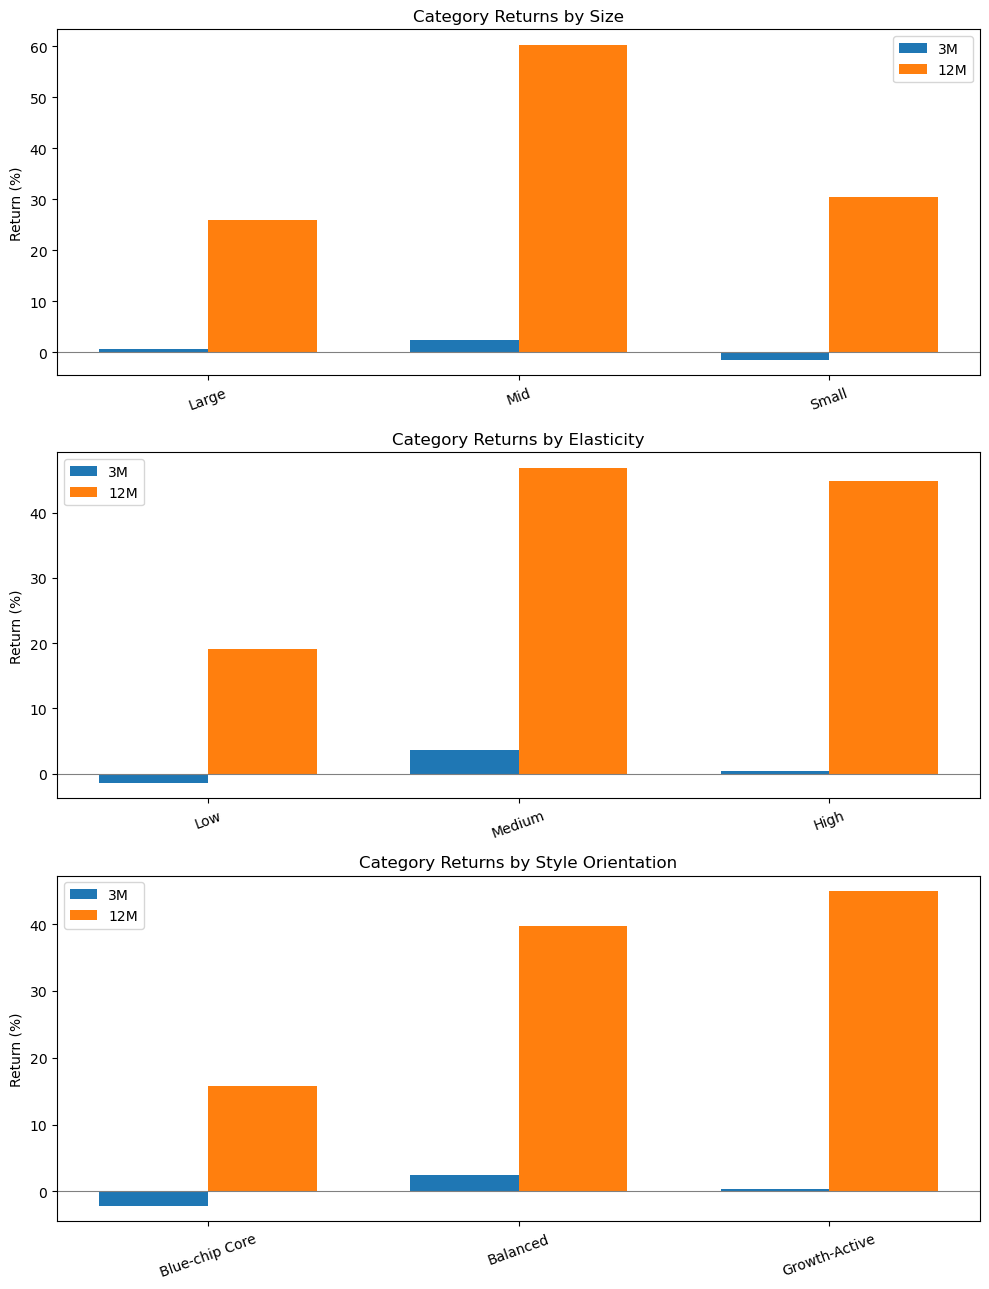

In [22]:
def draw_category_return_chart(ax, category_df, category_col, title_text):
    categories = list(category_df[category_col])
    x_positions_local = list(range(len(categories)))

    values_3m = []
    values_12m = []

    return_3m_list = list(category_df["return_3m"])
    return_12m_list = list(category_df["return_12m"])

    for i in range(len(category_df)):
        v3 = value_or_zero_for_plot(return_3m_list[i]) * 100
        v12 = value_or_zero_for_plot(return_12m_list[i]) * 100

        values_3m.append(v3)
        values_12m.append(v12)

    w = 0.35
    ax.bar([x - w / 2 for x in x_positions_local], values_3m, width=w, label="3M")
    ax.bar([x + w / 2 for x in x_positions_local], values_12m, width=w, label="12M")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(x_positions_local)
    ax.set_xticklabels(categories, rotation=20)
    ax.set_ylabel("Return (%)")
    ax.set_title(title_text)
    ax.legend()

fig, axes = plt.subplots(3, 1, figsize=(10, 13))
draw_category_return_chart(axes[0], size_return_df, "size", "Category Returns by Size")
draw_category_return_chart(axes[1], elasticity_return_df, "elasticity", "Category Returns by Elasticity")
draw_category_return_chart(axes[2], style_return_df, "style_orientation", "Category Returns by Style Orientation")
plt.tight_layout()
plt.show()



## 6. Activity Confirmation Analysis

This section uses trading amount and trading volume to examine whether the current price-based market style is supported by market activity.

In this project, two short-term activity indicators are used:
- amount ratio = recent 5-day average trading amount / recent 20-day average trading amount  
- volume ratio = recent 5-day average trading volume / recent 20-day average trading volume  

These indicators are first calculated at the individual-index level and then aggregated into category-level results across the same three dimensions used earlier:

- Size: large-cap, mid-cap, small-cap  
- Elasticity: low, medium, high  
- Style orientation: blue-chip core, balanced, growth-active  

The purpose of this section is to check whether the current price-leading style is also supported by stronger market participation.

Interpretation:
- If price-leading category also has strong activity -> leadership confirmed
- If price leads but activity is moderate (>average but not the first) -> limited confirmation
- If non-price-leading category has stronger activity -> may indicate potential rotation 

In [23]:
# Activity-based confirmation analysis.
# This block calculates short-term trading activity indicators for each included index.
# Then aggregates them into category-level results.
# In the end, checks whether the current price-leading style is also supported by stronger activity.


## Calculate short-term trading activity indicators for one index
def compute_activity_for_one_index(index_df, index_name):
    index_df = index_df.sort_values("date")

    amount_list = list(index_df["amount"])
    volume_list = list(index_df["volume"])

    amount_5 = amount_list[-5:]
    amount_20 = amount_list[-20:]
    volume_5 = volume_list[-5:]
    volume_20 = volume_list[-20:]
    
    ### Compute average trading amount and trading volume in 5 days and 20 days.
    avg_amount_5 = sum(amount_5) / len(amount_5)
    avg_amount_20 = sum(amount_20) / len(amount_20)
    avg_volume_5 = sum(volume_5) / len(volume_5)
    avg_volume_20 = sum(volume_20) / len(volume_20)

    return {
        "index": index_name,
        "amount_ratio": avg_amount_5 / avg_amount_20,
        "volume_ratio": avg_volume_5 / avg_volume_20,
    }


## Check whether the current price-leading category is also supported by stronger activity
def evaluate_activity_confirmation(price_leader_category, activity_category_df, category_column, dimension_name):
    categories = list(activity_category_df[category_column])
    amount_ratio_list = list(activity_category_df["amount_ratio"])
    volume_ratio_list = list(activity_category_df["volume_ratio"])
    
    ### Assuming the first category is the top categary and set the total activity score(amount ratio + volume ratio)
    top_cat = categories[0]
    top_score = float(amount_ratio_list[0]) + float(volume_ratio_list[0])
    
    ### Store the score of the current price-leading category and the total score
    leader_score = 0.0
    total_score = 0.0
    
    ### Compare all categories within this dimension
    for i in range(len(activity_category_df)):
        cat = categories[i]
        amt = float(amount_ratio_list[i])
        vol = float(volume_ratio_list[i])
        score = amt + vol

        total_score += score
        
        #### Update the strongest activity category if a higher score is found
        if score > top_score:
            top_score = score
            top_cat = cat

        if cat == price_leader_category:
            leader_score = score

    avg_score = total_score / len(activity_category_df)

    ### Strong confirmation: price leader is also the strongest in activity
    if top_cat == price_leader_category:
        return f"{dimension_name} dimension: price-leading category is {price_leader_category}, and activity is also strongest. leadership is confirmed."

    ### Limited confirmation: price leader is not the strongest, but still above the average activity level
    if leader_score >= avg_score:
        return f"{dimension_name} dimension: price-leading category is {price_leader_category}, activity is above average but not the strongest. confirmation is limited."

    ### Weak confirmation: another category shows stronger activity, which may suggest possible rotation
    return f"{dimension_name} dimension: price-leading category is {price_leader_category}, but activity is stronger in {top_cat}. which may indicate potential rotation."


## Build an index-level activity result table
activity_rows = []
for idx_name in included_indices:
    one_index_df = market_df[market_df["index"] == idx_name]

    one_activity = compute_activity_for_one_index(one_index_df, idx_name)
    one_activity["size"] = size_map[idx_name]
    one_activity["elasticity"] = elasticity_map[idx_name]
    one_activity["style_orientation"] = style_map[idx_name]

    activity_rows.append(one_activity)

activity_index_df = pd.DataFrame(activity_rows)


## Aggregate index-level activity results into category-level tables
size_activity_df = aggregate_by_category(activity_index_df, "size", ["amount_ratio", "volume_ratio"])
elasticity_activity_df = aggregate_by_category(activity_index_df, "elasticity", ["amount_ratio", "volume_ratio"])
style_activity_df = aggregate_by_category(activity_index_df, "style_orientation", ["amount_ratio", "volume_ratio"])


## Generate the final activity confirmation comments for the three dimensions
size_activity_comment = evaluate_activity_confirmation(
    size_leaders["current_leader_3m"], size_activity_df, "size", "Size"
)
elasticity_activity_comment = evaluate_activity_confirmation(
    elasticity_leaders["current_leader_3m"], elasticity_activity_df, "elasticity", "Elasticity"
)
style_activity_comment = evaluate_activity_confirmation(
    style_leaders["current_leader_3m"], style_activity_df, "style_orientation", "Style Orientation"
)


# Print the final activity-based summary only
print("\n[Activity Confirmation Conclusion]")
print(size_activity_comment)
print(elasticity_activity_comment)
print(style_activity_comment)


[Activity Confirmation Conclusion]
Size dimension: price-leading category is Mid, activity is above average but not the strongest. confirmation is limited.
Elasticity dimension: price-leading category is Medium, activity is above average but not the strongest. confirmation is limited.
Style Orientation dimension: price-leading category is Balanced, but activity is stronger in Growth-Active. which may indicate potential rotation.


### Visualization 4: Category-level amount_ratio and volume_ratio
This chart compares activity ratios (amount_ratio and volume_ratio) across categories.  
It helps us check whether price leadership is supported by stronger trading activity.

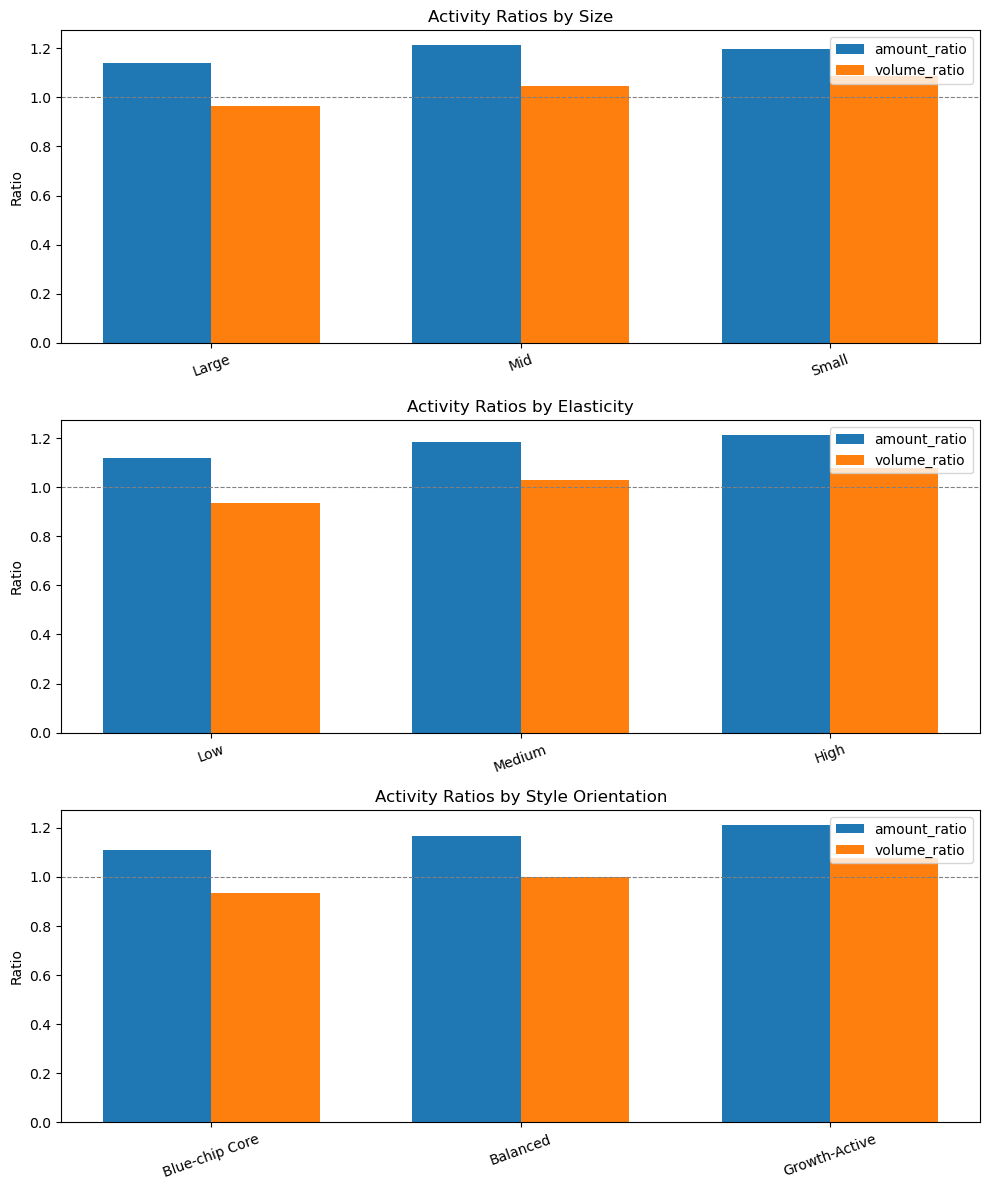

In [24]:
def draw_activity_chart(ax, activity_df, category_col, title_text):
    categories = list(activity_df[category_col])
    x_positions_local = list(range(len(categories)))

    amt_vals = []
    vol_vals = []

    amount_ratio_list = list(activity_df["amount_ratio"])
    volume_ratio_list = list(activity_df["volume_ratio"])

    for i in range(len(activity_df)):
        amt = value_or_zero_for_plot(amount_ratio_list[i])
        vol = value_or_zero_for_plot(volume_ratio_list[i])
        amt_vals.append(amt)
        vol_vals.append(vol)

    w = 0.35
    ax.bar([x - w / 2 for x in x_positions_local], amt_vals, width=w, label="amount_ratio")
    ax.bar([x + w / 2 for x in x_positions_local], vol_vals, width=w, label="volume_ratio")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xticks(x_positions_local)
    ax.set_xticklabels(categories, rotation=20)
    ax.set_ylabel("Ratio")
    ax.set_title(title_text)
    ax.legend()


fig, axes = plt.subplots(3, 1, figsize=(10, 12))
draw_activity_chart(axes[0], size_activity_df, "size", "Activity Ratios by Size")
draw_activity_chart(axes[1], elasticity_activity_df, "elasticity", "Activity Ratios by Elasticity")
draw_activity_chart(axes[2], style_activity_df, "style_orientation", "Activity Ratios by Style Orientation")
plt.tight_layout()
plt.show()




## 7. Final Style Summary

This section brings together the main results of the project. It summarises the market style over the past 12 months, the current market style, and whether a style shift may have happened.

The final conclusion is based on two parts:
- price-based analysis：shows the past and current leading styles
- activity confirmation analysis：checks whether the current style is supported by stronger trading activity

In this way, the project provides a clearer overall reading of the market instead of only looking at daily price movements.

In [25]:
summary_part_1 = "Market style over the past 12 months (12M): "
summary_part_1 += f"Size={size_leaders['past_leader_12m']},"
summary_part_1 += f"Elasticity={elasticity_leaders['past_leader_12m']},"
summary_part_1 += f"Style Orientation={style_leaders['past_leader_12m']}."

summary_part_2 = "\nCurrent market style (3M): "
summary_part_2 += f"Size={size_leaders['current_leader_3m']},"
summary_part_2 += f"Elasticity={elasticity_leaders['current_leader_3m']},"
summary_part_2 += f"Style Orientation={style_leaders['current_leader_3m']}."

summary_part_3 = "\nWhether style rotation occurred: "
summary_part_3 += f"Size={'Yes' if size_leaders['style_changed'] else 'No'}, "
summary_part_3 += f"Elasticity={'Yes' if elasticity_leaders['style_changed'] else 'No'}, "
summary_part_3 += f"Style Orientation={'Yes' if style_leaders['style_changed'] else 'No'}."

summary_part_4 = "\nActivity confirmation supplement: "
summary_part_4 += size_activity_comment
summary_part_4 += elasticity_activity_comment
summary_part_4 += style_activity_comment

final_summary_paragraph = summary_part_1 + summary_part_2 + summary_part_3 + summary_part_4

print("[Final Summary Paragraph]")
print(final_summary_paragraph)


[Final Summary Paragraph]
Market style over the past 12 months (12M): Size=Mid,Elasticity=Medium,Style Orientation=Growth-Active.
Current market style (3M): Size=Mid,Elasticity=Medium,Style Orientation=Balanced.
Whether style rotation occurred: Size=No, Elasticity=No, Style Orientation=Yes.
Activity confirmation supplement: Size dimension: price-leading category is Mid, activity is above average but not the strongest. confirmation is limited.Elasticity dimension: price-leading category is Medium, activity is above average but not the strongest. confirmation is limited.Style Orientation dimension: price-leading category is Balanced, but activity is stronger in Growth-Active. which may indicate potential rotation.


## 8. Limitations

This project has some limitations that should be acknowledged.

1. First, The classification framework is a product-oriented proxy, not strict academic factor classification.
2. Second, the category-level results are calculated using simple equal-weight averages. This approach is transparent and easy to understand, but it may oversimplify the relative importance of different indices.
3. Third, the activity confirmation analysis is based only on trading amount and trading volume. Although these indicators are useful for measuring short-term market participation, they do not represent all possible drivers of market style.
4. Finally, results depend on window settings (20/60/240, 5/20). However, different windows may lead to conclusions look slightly different.
